# 11 Semantic Drift Detection

**Project:** LLMOps Monitoring & Evaluation Platform

**Notebook:** `11-semantic-drift-detection.ipynb`

In [1]:
# Start coding here
# ==========================================
# Notebook 11
# Semantic Drift Detection
# ==========================================

import pandas as pd
import numpy as np

from sentence_transformers import SentenceTransformer

from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

d:\Books\projects-nlp-transformers-learning\.projectnlps\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [2]:
embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

In [3]:
historical_queries = [
    "AWS pricing information",
    "Azure storage costs",
    "Google Cloud services",
    "Cloud migration strategy",
    "Cloud infrastructure costs",
    "Cloud security best practices",
    "AWS compute pricing",
    "Azure VM costs",
]

In [4]:
current_queries = [
    "SOC2 compliance checklist",
    "Cybersecurity incident response",
    "Data breach prevention",
    "Identity access management",
    "Security governance framework",
    "Zero trust architecture",
    "Network security monitoring",
    "Threat intelligence platform",
]

In [5]:
historical_embeddings = embedding_model.encode(historical_queries)

current_embeddings = embedding_model.encode(current_queries)

In [6]:
historical_centroid = np.mean(historical_embeddings, axis=0)

In [7]:
current_centroid = np.mean(current_embeddings, axis=0)

In [8]:
centroid_similarity = cosine_similarity(
    historical_centroid.reshape(1, -1), current_centroid.reshape(1, -1)
)[0][0]

In [9]:
centroid_distance = 1 - centroid_similarity

centroid_distance

0.7549530267715454

In [10]:
def semantic_drift_score(baseline_queries, current_queries, model):

    baseline_embeddings = model.encode(baseline_queries)

    current_embeddings = model.encode(current_queries)

    baseline_centroid = np.mean(baseline_embeddings, axis=0)

    current_centroid = np.mean(current_embeddings, axis=0)

    similarity = cosine_similarity(
        baseline_centroid.reshape(1, -1), current_centroid.reshape(1, -1)
    )[0][0]

    distance = 1 - similarity

    return {
        "similarity": round(float(similarity), 4),
        "distance": round(float(distance), 4),
    }

In [11]:
semantic_drift_score(historical_queries, current_queries, embedding_model)

{'similarity': 0.245, 'distance': 0.755}

In [12]:
def drift_label(distance):

    if distance < 0.10:

        return "No Drift"

    elif distance < 0.25:

        return "Minor Drift"

    elif distance < 0.40:

        return "Moderate Drift"

    return "Major Drift"

In [13]:
result = semantic_drift_score(historical_queries, current_queries, embedding_model)

drift_label(result["distance"])

'Major Drift'

In [14]:
monthly_distances = [0.05, 0.08, 0.11, 0.15, 0.21, 0.27, 0.34, 0.42]

In [15]:
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug"]

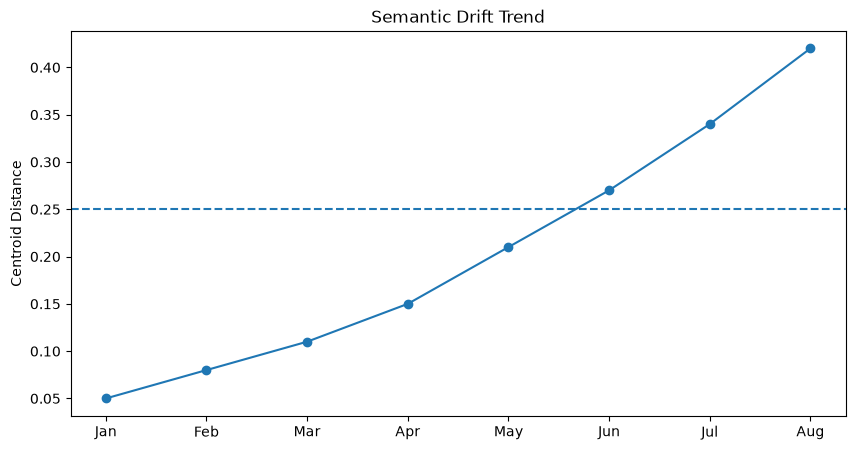

In [16]:
plt.figure(figsize=(10, 5))

plt.plot(months, monthly_distances, marker="o")

plt.axhline(y=0.25, linestyle="--")

plt.title("Semantic Drift Trend")

plt.ylabel("Centroid Distance")

plt.show()

In [17]:
DRIFT_THRESHOLD = 0.25

In [18]:
def check_drift_alert(distance):

    return distance > DRIFT_THRESHOLD

In [19]:
check_drift_alert(result["distance"])

True

In [20]:
drift_df = pd.DataFrame({"month": months, "distance": monthly_distances})

In [21]:
drift_df["status"] = drift_df["distance"].apply(drift_label)

In [22]:
drift_df

,month,distance,status
0,Jan,0.05,No Drift
1,Feb,0.08,No Drift
2,Mar,0.11,Minor Drift
3,Apr,0.15,Minor Drift
4,May,0.21,Minor Drift
5,Jun,0.27,Moderate Drift
6,Jul,0.34,Moderate Drift
7,Aug,0.42,Major Drift


In [23]:
WINDOW_SIZE = 1000

In [24]:
def simple_psi(expected, actual):

    expected = np.array(expected)

    actual = np.array(actual)

    psi = np.sum((actual - expected) * np.log(actual / expected))

    return psi

In [25]:
expected = [0.2, 0.3, 0.5]

actual = [0.1, 0.4, 0.5]

simple_psi(expected, actual)

0.09808292530117263

In [26]:
drift_df.to_csv("../evaluation_results/drift_monitoring.csv", index=False)

In [27]:
alert = {
    "timestamp": "2026-06-20",
    "drift_score": result["distance"],
    "status": drift_label(result["distance"]),
}

alert

{'timestamp': '2026-06-20', 'drift_score': 0.755, 'status': 'Major Drift'}